In [1]:
## Import required libraries

import cv2                      # OpenCV for image processing
import os                       # For folder and file handling
import numpy as np              # Numerical operations
import matplotlib.pyplot as plt # Display images
from ultralytics import YOLO    # YOLO model

In [2]:
# Load YOLOv8 model
model = YOLO("yolov8n.pt")

In [4]:
# Set dataset folder path
dataset_path = r"D:\Computer Vision\fake_logo"

In [5]:
# Store original logos
original_logos = {}

# Read dataset folders
folders = os.listdir(dataset_path)

for folder in folders:

    # Use only genuine folders
    if "genuine" in folder:

        folder_path = os.path.join(dataset_path, folder)

        # Read first image
        image_name = os.listdir(folder_path)[0]

        image_path = os.path.join(folder_path, image_name)

        img = cv2.imread(image_path)

        if img is not None:

            # Convert to grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Brand name
            brand = folder.split("_")[0]

            original_logos[brand] = gray

print("Loaded Brands:")
print(original_logos.keys())

Loaded Brands:
dict_keys([])


In [6]:
# ORB feature detector
orb = cv2.ORB_create()

In [7]:
# Function to compare two logo images
def compare_logo(img1, img2):

    # Resize images
    img1 = cv2.resize(img1, (200, 200))
    img2 = cv2.resize(img2, (200, 200))

    # Detect features
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    # If descriptors missing
    if des1 is None or des2 is None:
        return 0

    # Match features
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    matches = bf.match(des1, des2)

    return len(matches)

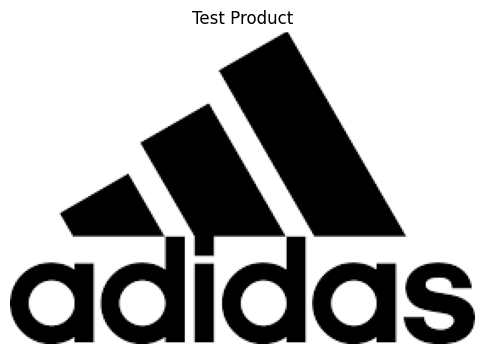

In [9]:
# Test image path
test_image_path = "fake_logo/adidas/1.png"

# Read image
test_image = cv2.imread(test_image_path)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.title("Test Product")
plt.axis("off")
plt.show()

In [10]:
# Run YOLO detection
results = model(test_image)

# Show detection result
results[0].show()


0: 448x640 4 traffic lights, 1 tie, 65.4ms
Speed: 7.7ms preprocess, 65.4ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


In [11]:
import streamlit as st
# Get image size
h, w, _ = test_image.shape

# Crop center area (logo area)
logo_crop = test_image[
    int(h*0.3):int(h*0.7),
    int(w*0.3):int(w*0.7)
]

# Show cropped logo
st.image(
    cv2.cvtColor(logo_crop, cv2.COLOR_BGR2RGB),
    caption="Detected Logo Area",
    use_container_width=True
)

# Convert cropped image to grayscale
test_gray = cv2.cvtColor(logo_crop, cv2.COLOR_BGR2GRAY)

2026-05-18 11:50:39.440 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-05-18 11:50:39.440 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:50:39.448 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:50:39.560 
  command:

    streamlit run C:\Users\Akrit\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-18 11:50:39.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 11:50:39.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [15]:
import cv2
import os

# ==========================================
# DATASET PATH
# ==========================================

dataset_path = r"D:\Computer Vision\fake_logo"

# ==========================================
# LOAD LOGOS
# ==========================================

logos = {}

brands = os.listdir(dataset_path)

print("Brands Found:")
print(brands)

for brand in brands:

    brand_path = os.path.join(dataset_path, brand)

    logos[brand] = []

    print("\nChecking:", brand)

    files = os.listdir(brand_path)

    print("Images:", files)

    for file in files:

        path = os.path.join(brand_path, file)

        img = cv2.imread(path, 0)

        if img is None:

            print("Image not loaded:", path)

        else:

            logos[brand].append(img)

            print("Loaded:", file)

# ==========================================
# FINAL CHECK
# ==========================================

print("\nFinal Logos Loaded:\n")

for brand in logos:

    print(brand, ":", len(logos[brand]))

Brands Found:
['adidas', 'BMW', 'coca cola', 'dabur', 'google', 'microsoft', 'nike']

Checking: adidas
Images: ['1.png', '10.png', '11.png', '12.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png']
Loaded: 1.png
Loaded: 10.png
Loaded: 11.png
Loaded: 12.png
Loaded: 2.png
Loaded: 3.png
Loaded: 4.png
Loaded: 5.png
Loaded: 6.png
Loaded: 7.png
Loaded: 8.png
Loaded: 9.png

Checking: BMW
Images: ['1.png', '10.png', '11.png', '12.png', '13.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png']
Loaded: 1.png
Loaded: 10.png
Loaded: 11.png
Loaded: 12.png
Loaded: 13.png
Loaded: 2.png
Loaded: 3.png
Loaded: 4.png
Loaded: 5.png
Loaded: 6.png
Loaded: 7.png
Loaded: 8.png
Loaded: 9.png

Checking: coca cola
Images: ['1.png', '10.png', '11.png', '12.png', '13.png', '14.png', '15.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.jpg', '8.png', '9.png']
Loaded: 1.png
Loaded: 10.png
Loaded: 11.png
Loaded: 12.png
Loaded: 13.png
Loaded: 14.png
Loaded: 15.png


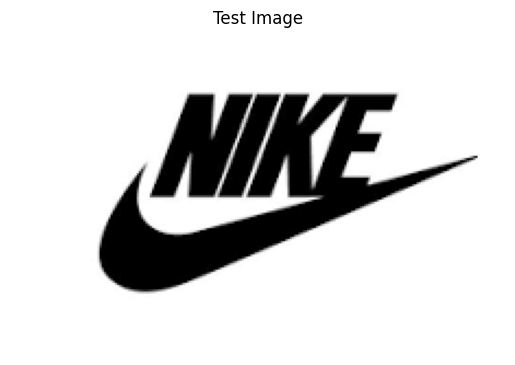

adidas Average Score: 2.0
BMW Average Score: 2.8461538461538463
coca cola Average Score: 2.3333333333333335
dabur Average Score: 5.181818181818182
google Average Score: 2.3333333333333335
microsoft Average Score: 2.090909090909091
nike Average Score: 14.88888888888889

Detected Brand: nike
Matching Score: 14.88888888888889
REAL LOGO


In [20]:
# Create SIFT feature detector
sift = cv2.SIFT_create()

def compare_images(img1, img2):

    img1 = cv2.resize(img1, (300,300))
    img2 = cv2.resize(img2, (300,300))

    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    good = []

    for m,n in matches:

        if m.distance < 0.75 * n.distance:
            good.append(m)

    return len(good)

# ======================================
# TEST IMAGE
# ======================================

test_path = r"D:\Computer Vision\fake_logo\nike\2.png"

test_img = cv2.imread(test_path, 0)

plt.imshow(test_img, cmap='gray')
plt.title("Test Image")
plt.axis("off")
plt.show()

# ======================================
# MATCHING
# ======================================

best_brand = ""
best_score = 0

for brand, images in logos.items():

    total = 0

    for logo in images:

        score = compare_images(test_img, logo)

        total += score

    avg_score = total / len(images)

    print(brand, "Average Score:", avg_score)

    if avg_score > best_score:

        best_score = avg_score
        best_brand = brand

# ======================================
# RESULT
# ======================================

print("\nDetected Brand:", best_brand)
print("Matching Score:", best_score)

if best_score > 10:
    print("REAL LOGO")
else:
    print("FAKE LOGO")